## Matrice de corrélation avec clustering hiérarchique

Corrélations fortes (|r| ≥ 0.8) :
🔴 Nationality Group ↔ International : 0.8478
🔴 Mother's occupation ↔ Father's occupation : 0.8548
🔴 Curricular units 1st sem (credited) ↔ Curricular units 2nd sem (credited) : 0.9472
🔴 Curricular units 1st sem (enrolled) ↔ Curricular units 2nd sem (enrolled) : 0.9413
🔴 Curricular units 1st sem (approved) ↔ Curricular units 2nd sem (approved) : 0.9164
🔴 Curricular units 1st sem (grade) ↔ Curricular units 2nd sem (grade) : 0.8458


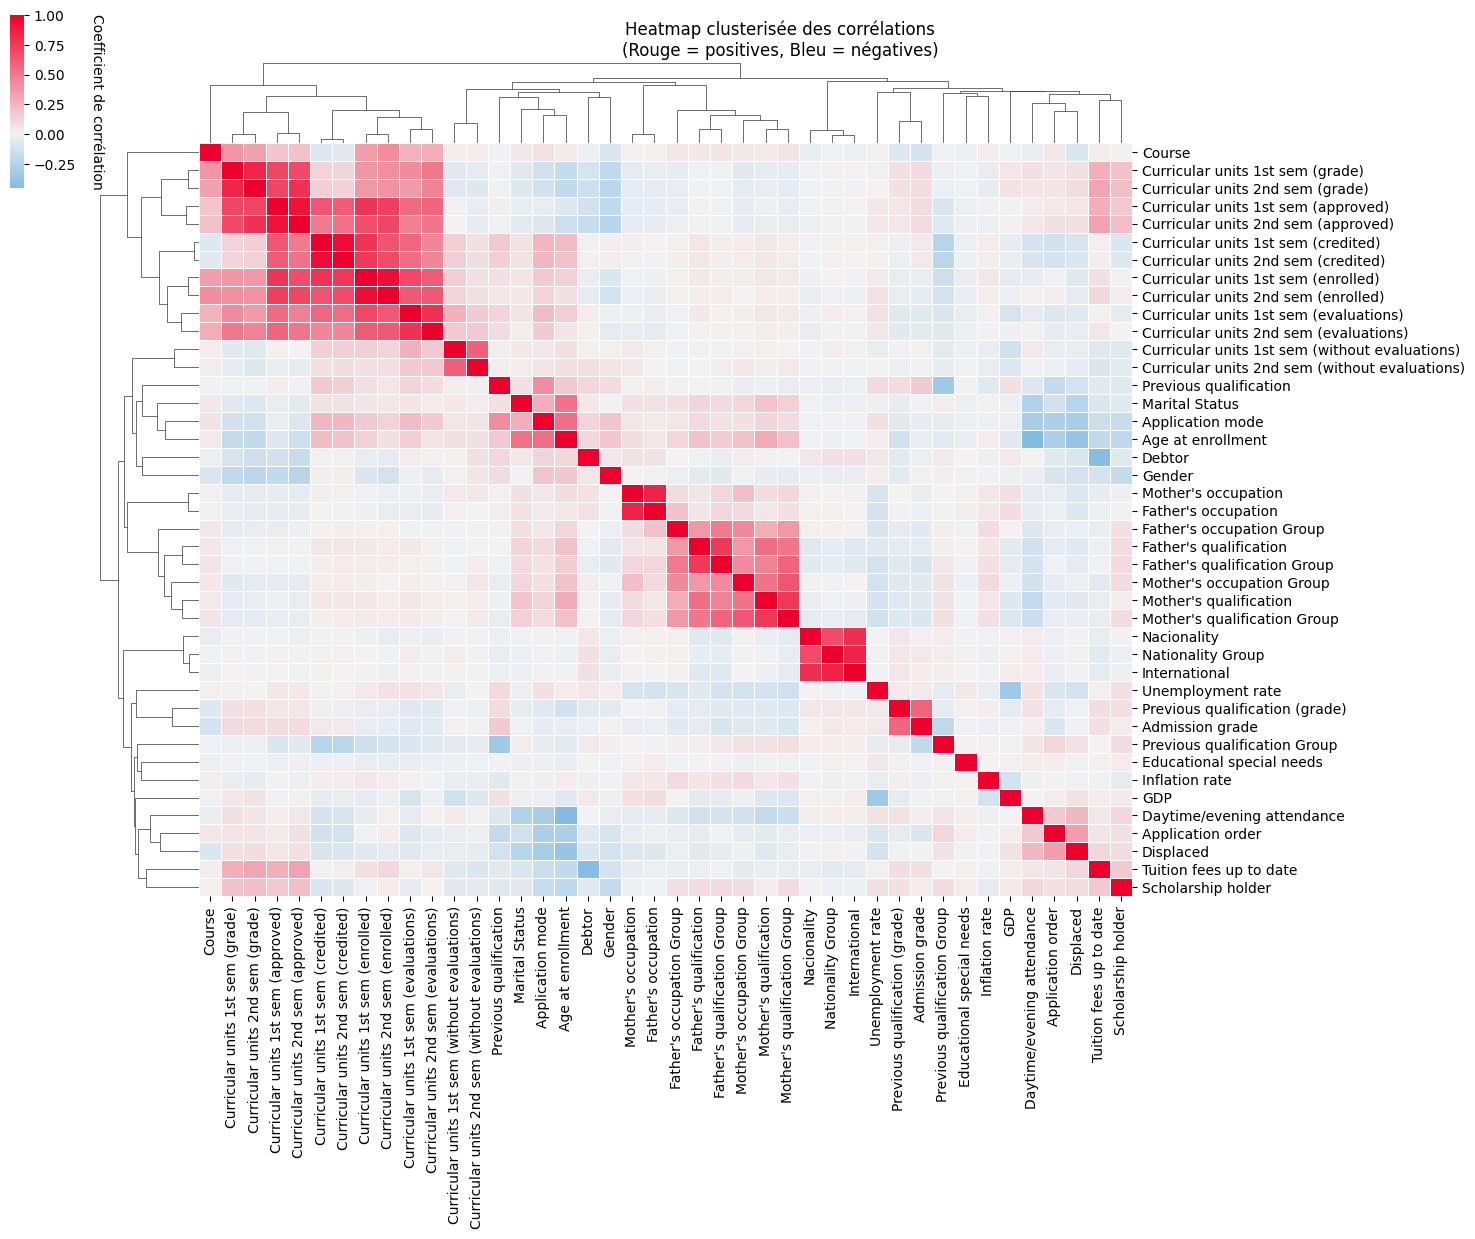

In [ ]:
# 📊 MATRICE DE CORRÉLATION COMPLÈTE AVEC HEATMAP CLUSTERISÉE
# ════════════════════════════════════════════════════════════════════════════
# Description: Génération d'une matrice de corrélation complète avec une heatmap clusterisée
# ════════════════════════════════════════════════════════════════════════════

# _________________ 1️⃣  IMPORTATION DES LIBRAIRIES _______________________
# Import des librairies nécessaires

import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
import warnings
warnings.filterwarnings('ignore')

# _________________ 2️⃣  CHARGEMENT DES DONNÉES _______________________
# Recharger le fichier CSV pour s'assurer de partir d'une version propre
df = pd.read_csv(Path.cwd().parent / 'data' / 'data_update.csv', delimiter=';')

# --- Sélection des colonnes numériques uniquement ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[num_cols]

# --- Calcul de la matrice de corrélation ---
corr_matrix = df_numeric.corr()

# --- Extraction des corrélations fortes (|r| ≥ 0.8) ---
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.8:
            strong_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], val))

# --- Affichage des paires fortement corrélées dans la console ---
print("Corrélations fortes (|r| ≥ 0.8) :")
for var1, var2, val in strong_pairs:
    sign = "🔴" if val > 0 else "🔵"  # Rouge si positive, bleu sinon
    print(f"{sign} {var1} ↔ {var2} : {val:.4f}")

# --- Création de la palette rouge-blanc-bleu pour heatmap ---
cmap = sns.diverging_palette(250, 10, s=100, l=50, as_cmap=True)

# --- Calcul du clustering hiérarchique pour ordonner les variables ---
link_rows = linkage(corr_matrix, method='average')
link_cols = linkage(corr_matrix.T, method='average')

# --- Génération et affichage de la heatmap clusterisée complète ---
g = sns.clustermap(
    corr_matrix,
    row_linkage=link_rows,
    col_linkage=link_cols,
    cmap=cmap,
    center=0,
    linewidths=0.5,
    figsize=(14, 12),
    cbar_kws={'label': 'Coefficient de corrélation'},
    dendrogram_ratio=(0.1, 0.1),
)

# Récupérer la position actuelle de la colorbar (BBox)
pos = g.cax.get_position()

# Déplacer la colorbar horizontalement (x0, x1) ou verticalement (y0, y1)
# Exemple pour décaler vers la gauche (plus petit x0 et x1)
new_pos = [pos.x0 - 0.07, pos.y0 + 0.08, pos.width, pos.height]

# Appliquer la nouvelle position
g.cax.set_position(new_pos)

# Modifier la taille de la police du label de la colorbar
g.cax.set_ylabel('Coefficient de corrélation', fontsize=10, rotation=270, labelpad=20)

# Modifier la taille et le ratio de la colorbar (l'axe lui-même)
pos = g.cax.get_position()
g.cax.set_position([pos.x0, pos.y0, pos.width * 0.2, pos.height * 0.8])  # Multiplier taille

plt.suptitle('Heatmap clusterisée des corrélations\n(Rouge = positives, Bleu = négatives)', y=1.02)


filename = os.path.join(graphiques_folder, "matrice_correlation.png")
g.savefig(filename)

plt.show()


## PCA 

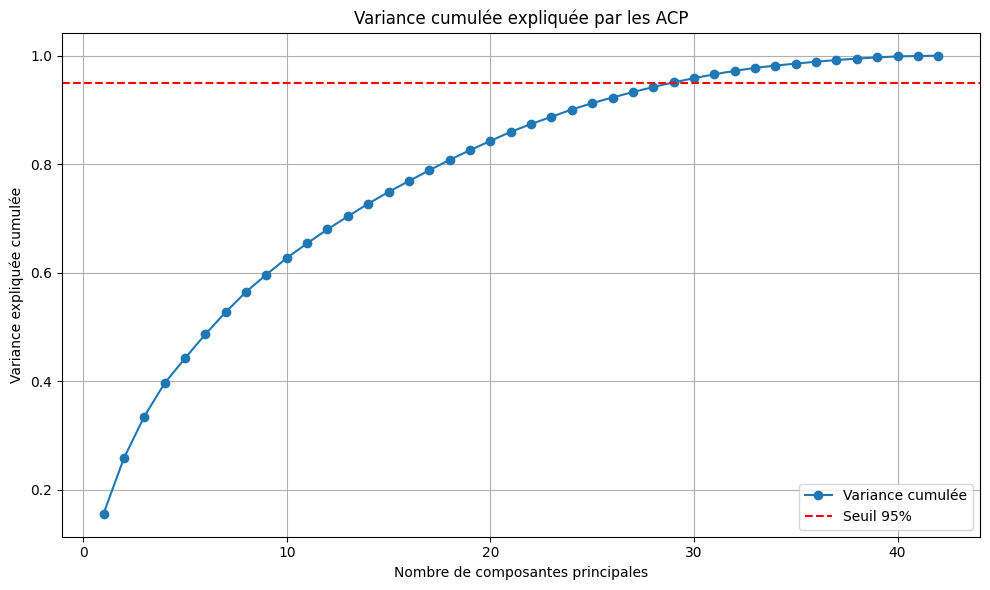

Nombre de composantes nécessaires pour expliquer 95% de la variance : 29


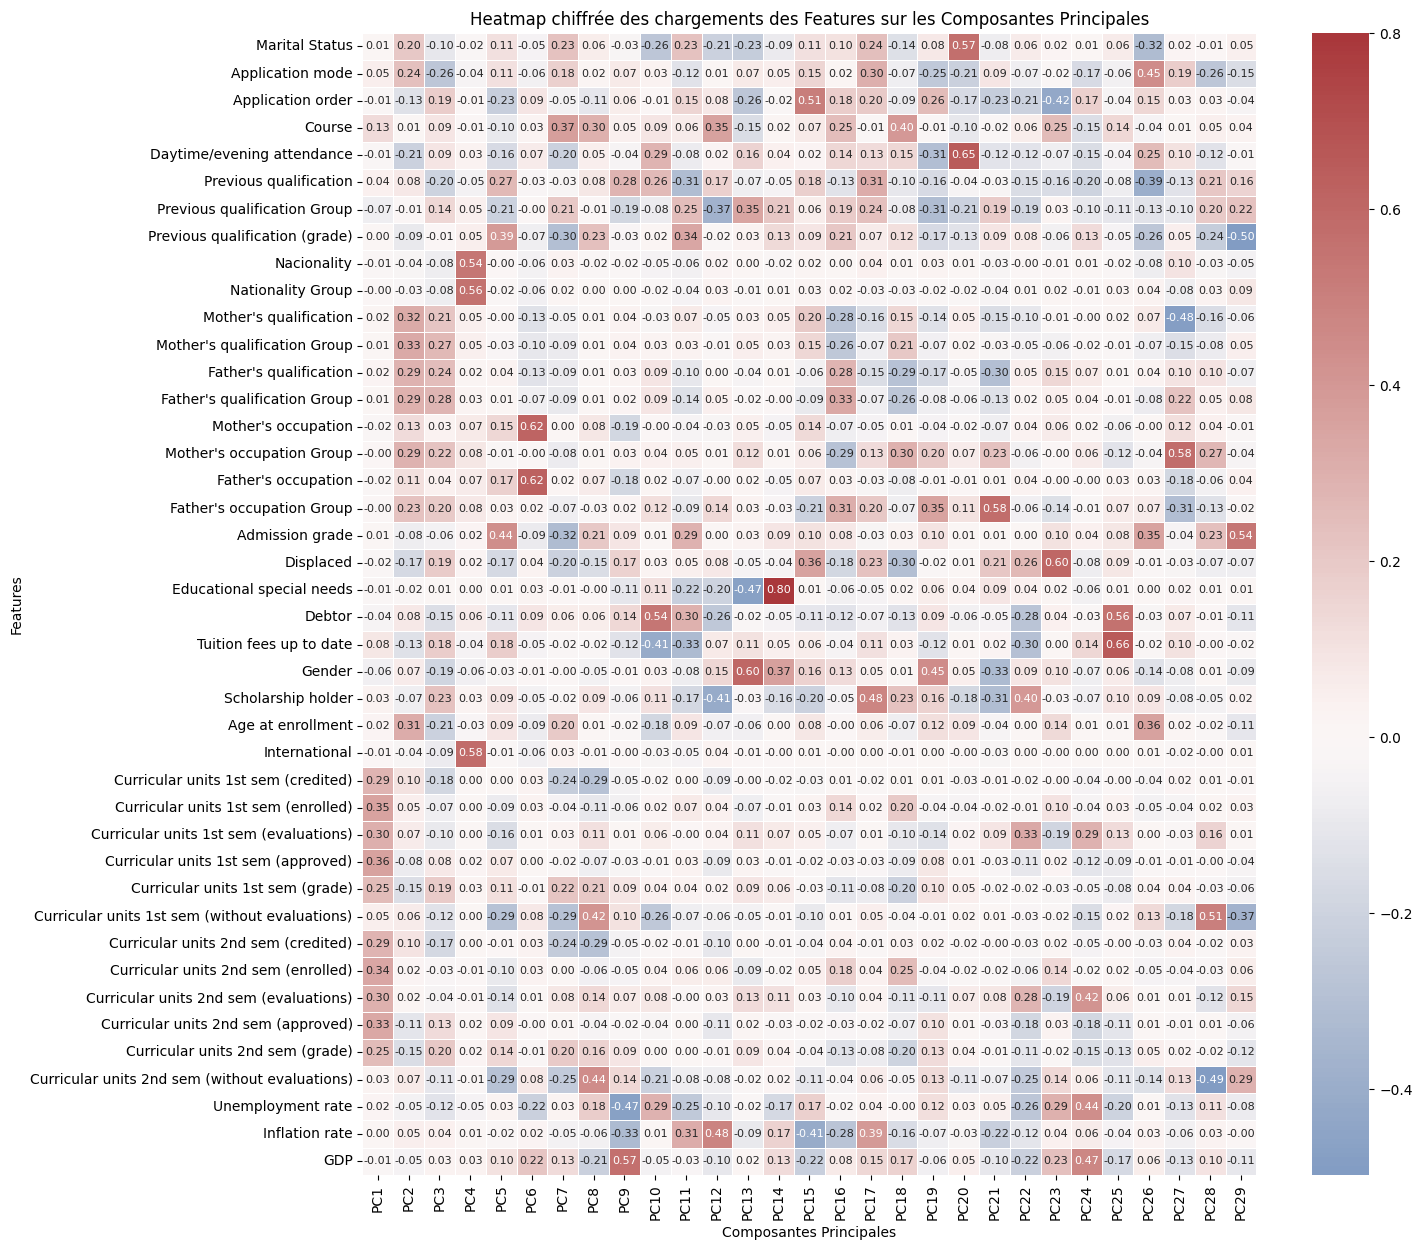


Composante PC1 :
 - Curricular units 1st sem (approved): 0.356
 - Curricular units 1st sem (enrolled): 0.353
 - Curricular units 2nd sem (enrolled): 0.344
 - Curricular units 2nd sem (approved): 0.334
 - Curricular units 1st sem (evaluations): 0.300

Composante PC2 :
 - Mother's qualification Group: 0.326
 - Mother's qualification: 0.321
 - Age at enrollment: 0.314
 - Father's qualification Group: 0.295
 - Father's qualification: 0.292

Composante PC3 :
 - Father's qualification Group: 0.278
 - Mother's qualification Group: 0.266
 - Application mode: -0.260
 - Father's qualification: 0.243
 - Scholarship holder: 0.232

Composante PC4 :
 - International: 0.581
 - Nationality Group: 0.557
 - Nacionality: 0.542
 - Mother's occupation Group: 0.084
 - Father's occupation Group: 0.080

Composante PC5 :
 - Admission grade: 0.436
 - Previous qualification (grade): 0.387
 - Curricular units 1st sem (without evaluations): -0.294
 - Curricular units 2nd sem (without evaluations): -0.292
 - Previ

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

# --- Sélection des variables numériques ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[num_cols].copy()

# --- Standardisation des variables ---
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric)

# --- PCA avec sklearn ---
pca = PCA()
pca_result = pca.fit_transform(data_scaled)

# --- Variance expliquée par chaque composante ---
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Graphique de la variance expliquée cumulée ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', label='Variance cumulée')
plt.axhline(y=0.95, color='r', linestyle='--', label='Seuil 95%')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance cumulée expliquée par les ACP')
plt.legend()
plt.grid(True)
plt.tight_layout()
filename = os.path.join(graphiques_folder, "variance_cumulee_acp.png")
plt.savefig(filename)
plt.show()

# --- Affichage du nombre de composantes nécessaires pour atteindre 95% ---
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Nombre de composantes nécessaires pour expliquer 95% de la variance : {n_95}")

# --- PCA avec le nombre optimal de composantes ---
pca_opt = PCA(n_components=n_95)
pca_result_opt = pca_opt.fit_transform(data_scaled)

# --- Création dataframe des chargements ---
loadings = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(n_95)],
    index=num_cols
)

# --- Heatmap chiffrée des chargements ---
plt.figure(figsize=(15, max(8, len(num_cols)*0.3)))  # Fenêtre plus large et haute
sns.heatmap(
    loadings,
    cmap='vlag',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    annot_kws={'size': 8}  # Taille réduite des chiffres dans les cases
)
plt.title('Heatmap chiffrée des chargements des Features sur les Composantes Principales')
plt.xlabel('Composantes Principales')
plt.ylabel('Features')
plt.tight_layout()
filename = os.path.join(graphiques_folder, "heatmap_acp.png")
plt.savefig(filename)
plt.show()

# --- Extraction des features les plus importantes par composante principale ---
def top_features_per_pc(loadings_df, top_n=5):
    tops = {}
    for pc in loadings_df.columns:
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False).head(top_n).index
        tops[pc] = list(zip(sorted_features, loadings_df.loc[sorted_features, pc]))
    return tops

important_features = top_features_per_pc(loadings)

# --- Affichage des features clés ---
for pc, feats in important_features.items():
    print(f"\nComposante {pc} :")
    for feat, val in feats:
        print(f" - {feat}: {val:.3f}")




# FAMD (Factor Analysis for Mixed Data)

In [ ]:
# famd_proper.py
# VRAIE FAMD = PCA (continu) + MCA (catégories) combinées correctement

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

# ============================================================================
# CLASSE MCA SIMPLIFIÉE
# ============================================================================

class SimpleMCA:
    """Implémentation simplifiée de MCA (Multiple Correspondence Analysis)"""
    
    def __init__(self, n_components=5, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.encoder = None
        self.pca = None
        self.feature_names = None
        
    def fit(self, X):
        """Fit MCA sur données catégorielles"""
        # Encode one-hot
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        X_encoded = self.encoder.fit_transform(X)
        
        # Normalise pour MCA
        X_normalized = X_encoded / X_encoded.sum(axis=1, keepdims=True)
        
        # PCA sur données encodées
        self.pca = PCA(n_components=self.n_components, random_state=self.random_state)
        self.pca.fit(X_normalized)
        
        return self
    
    def transform(self, X):
        """Transforme données catégorielles"""
        X_encoded = self.encoder.transform(X)
        X_normalized = X_encoded / X_encoded.sum(axis=1, keepdims=True)
        return self.pca.transform(X_normalized)
    
    @property
    def explained_variance_ratio_(self):
        return self.pca.explained_variance_ratio_


# ============================================================================
# CLASSE FAMD PROPRE
# ============================================================================

class ProperFAMD:
    """
    Vraie FAMD = PCA sur continu + MCA sur catégories
    puis combinaison des deux
    """
    
    def __init__(self, n_components=10, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.pca_continuous = None
        self.mca_categorical = None
        self.scaler_continuous = None
        self.continuous_cols = []
        self.categorical_cols = []
        
    def fit(self, X):
        """Fit la FAMD"""
        # Identifie types de colonnes
        for col in X.columns:
            # Option 1 : Basé sur le type pandas
            if X[col].dtype in ['object', 'category']:
                self.categorical_cols.append(col)
            else:
                self.continuous_cols.append(col)
        
        print(f"Données identifiées:")
        print(f"  • Continues: {len(self.continuous_cols)} colonnes")
        print(f"  • Catégorielles: {len(self.categorical_cols)} colonnes")
        
        # Sépare et prépare les données
        X_continuous = X[self.continuous_cols].copy()
        X_categorical = X[self.categorical_cols].copy()
        
        # === ÉTAPE 1 : PCA sur continues ===
        if len(self.continuous_cols) > 0:
            print(f"\n📊 PCA sur {len(self.continuous_cols)} variables continues...")
            self.scaler_continuous = StandardScaler()
            X_cont_scaled = self.scaler_continuous.fit_transform(X_continuous)
            
            n_comp_pca = max(1, int(self.n_components * 0.6))  # 60% des composantes
            self.pca_continuous = PCA(n_components=n_comp_pca, random_state=self.random_state)
            self.pca_continuous.fit(X_cont_scaled)
            
            var_pca = self.pca_continuous.explained_variance_ratio_.sum()
            print(f"  ✓ {n_comp_pca} composantes PCA")
            print(f"  ✓ Variance expliquée: {var_pca:.1%}")
        
        # === ÉTAPE 2 : MCA sur catégorielles ===
        if len(self.categorical_cols) > 0:
            print(f"\n📊 MCA sur {len(self.categorical_cols)} variables catégorielles...")
            n_comp_mca = max(1, int(self.n_components * 0.4))  # 40% des composantes
            self.mca_categorical = SimpleMCA(n_components=n_comp_mca, random_state=self.random_state)
            self.mca_categorical.fit(X_categorical)
            
            var_mca = self.mca_categorical.explained_variance_ratio_.sum()
            print(f"  ✓ {n_comp_mca} composantes MCA")
            print(f"  ✓ Variance expliquée: {var_mca:.1%}")
        
        return self
    
    def transform(self, X):
        """Transforme données"""
        X_continuous = X[self.continuous_cols].copy()
        X_categorical = X[self.categorical_cols].copy()
        
        components = []
        
        # Transform PCA
        if self.pca_continuous is not None:
            X_cont_scaled = self.scaler_continuous.transform(X_continuous)
            pca_scores = self.pca_continuous.transform(X_cont_scaled)
            components.append(pca_scores)
        
        # Transform MCA
        if self.mca_categorical is not None:
            mca_scores = self.mca_categorical.transform(X_categorical)
            components.append(mca_scores)
        
        # Combine
        X_combined = np.hstack(components)
        
        # Crée dataframe
        col_names = []
        if self.pca_continuous is not None:
            col_names.extend([f'PCA_{i+1}' for i in range(self.pca_continuous.n_components_)])
        if self.mca_categorical is not None:
            col_names.extend([f'MCA_{i+1}' for i in range(self.mca_categorical.n_components)])
        
        return pd.DataFrame(X_combined, columns=col_names)
    
    def fit_transform(self, X):
        """Fit et transform"""
        self.fit(X)
        return self.transform(X)


# ============================================================================
# SCRIPT PRINCIPAL
# ============================================================================

print("="*70)
print("📊 VRAIE FAMD (PCA + MCA) - Graduate/Dropout Dataset")
print("="*70)

# 1. CHARGEMENT
df = pd.read_csv('data_graduate_dropout.csv', sep=';')
print(f"\n✓ Données chargées: {df.shape[0]} lignes × {df.shape[1]} colonnes")

X = df.drop('Target', axis=1)
y = df['Target']

print(f"  Features: {X.shape[1]}")
print(f"  Target: {y.value_counts().to_dict()}")

# 2. APPLICATION FAMD PROPRE
print("\n" + "-"*70)
print("🔄 Application FAMD propre (PCA + MCA)...")
print("-"*70)

famd = ProperFAMD(n_components=10, random_state=42)
X_famd = famd.fit_transform(X)

print(f"\n✓ FAMD appliquée")
print(f"  Original: {X.shape[1]} colonnes")
print(f"  Après: {X_famd.shape[1]} composantes")
print(f"  Réduction: -{(1 - X_famd.shape[1]/X.shape[1])*100:.0f}%")

print(f"\nComposition des composantes:")
n_pca = famd.pca_continuous.n_components_ if famd.pca_continuous else 0
n_mca = famd.mca_categorical.n_components if famd.mca_categorical else 0
print(f"  • {n_pca} composantes PCA (variables continues)")
print(f"  • {n_mca} composantes MCA (variables catégorielles)")

# 3. ANALYSE VARIANCE
print("\n" + "-"*70)
print("📈 Variance expliquée")
print("-"*70)

if famd.pca_continuous:
    var_pca = famd.pca_continuous.explained_variance_ratio_
    print(f"\nPCA (continues):")
    for i in range(min(5, len(var_pca))):
        print(f"  PC{i+1}: {var_pca[i]:.2%}")
    print(f"  Total ({len(var_pca)} composantes): {var_pca.sum():.2%}")

if famd.mca_categorical:
    var_mca = famd.mca_categorical.explained_variance_ratio_
    print(f"\nMCA (catégorielles):")
    for i in range(min(5, len(var_mca))):
        print(f"  MC{i+1}: {var_mca[i]:.2%}")
    print(f"  Total ({len(var_mca)} composantes): {var_mca.sum():.2%}")

# 4. SAUVEGARDE
print("\n" + "-"*70)
print("💾 Sauvegarde")
print("-"*70)

X_famd.to_csv('famd_proper_scores.csv', index=False)
print("✓ famd_proper_scores.csv")

famd_with_target = X_famd.copy()
famd_with_target['Target'] = y.values
famd_with_target.to_csv('famd_proper_scores_with_target.csv', index=False)
print("✓ famd_proper_scores_with_target.csv")

# 5. RÉSUMÉ COMPARATIF
print("\n" + "="*70)
print("✅ VRAIE FAMD (PCA + MCA) terminée !")
print("="*70)

print(f"""
Approche FAMD Propre:
  • Variables continues: {len(famd.continuous_cols)}
  • Variables catégorielles: {len(famd.categorical_cols)}
  • Composantes PCA: {n_pca}
  • Composantes MCA: {n_mca}
  • Total composantes: {X_famd.shape[1]}
  
Réduction: {X.shape[1]} colonnes → {X_famd.shape[1]} composantes (-{(1-X_famd.shape[1]/X.shape[1])*100:.0f}%)

Fichiers générés:
  ✓ famd_proper_scores.csv
  ✓ famd_proper_scores_with_target.csv
""")